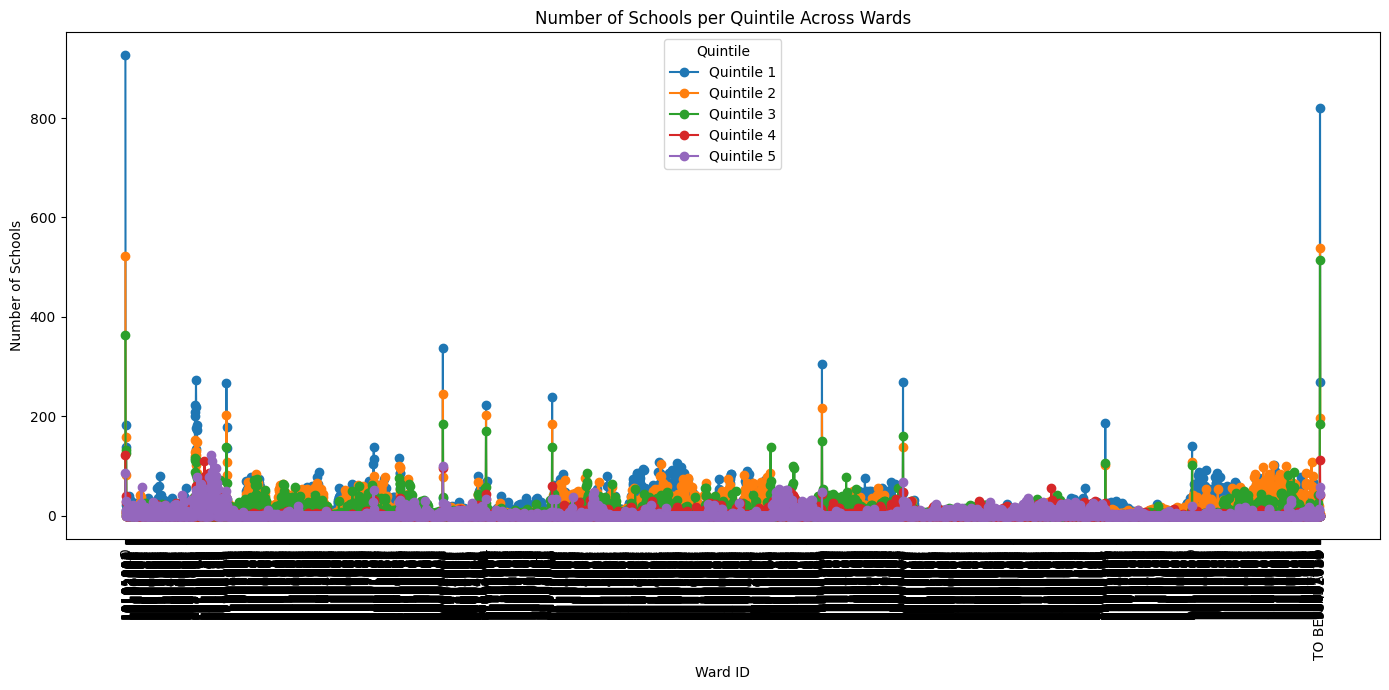

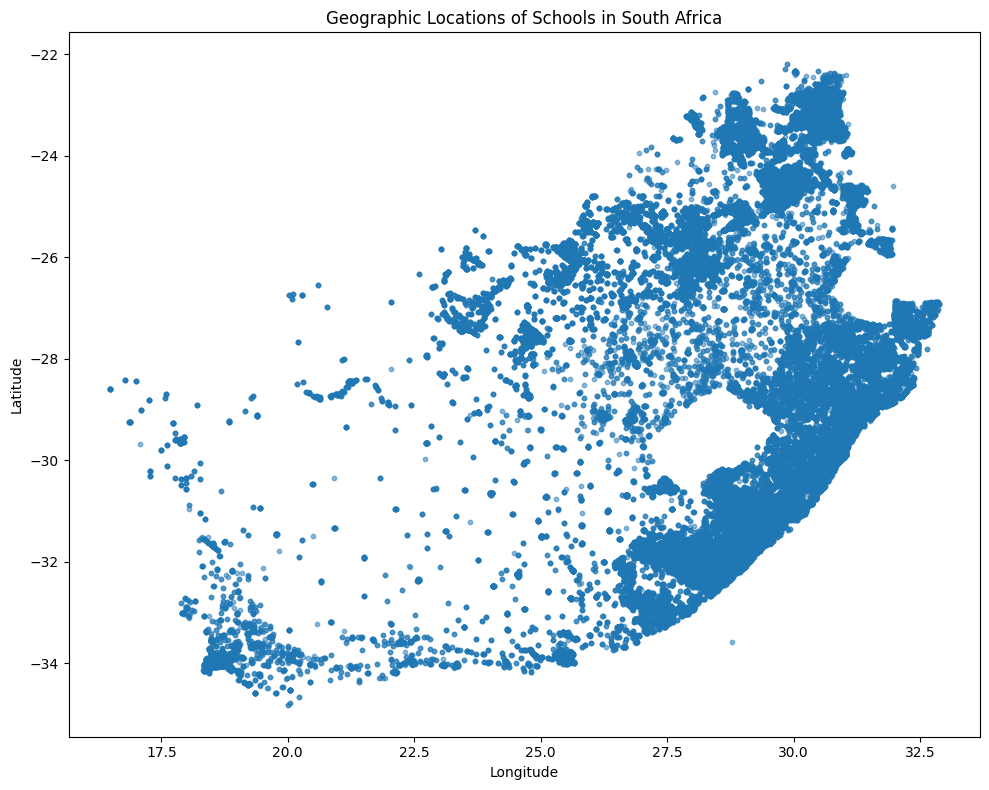

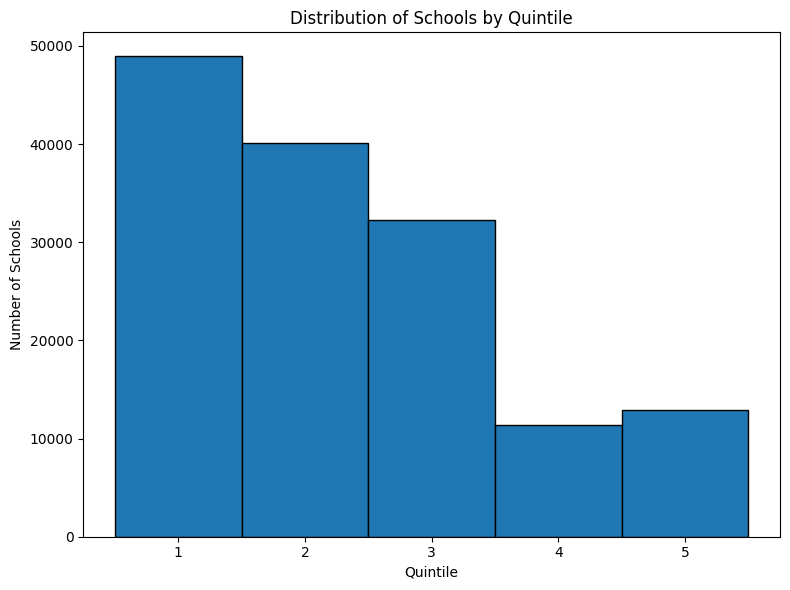

Figures saved successfully in: genAI_model_1_figures
Files created:
- a_schools_per_quintile_across_wards.png
- b_school_geographic_locations.png
- c_distribution_of_schools_by_quintile.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ============================================================
# CREATE OUTPUT FOLDER
# ============================================================

# Create a folder to store all generated figures.
# exist_ok=True means the code will not produce an error
# if the folder already exists.
output_folder = "genAI_model_1_figures"
os.makedirs(output_folder, exist_ok=True)


# ============================================================
# LOAD THE DATA
# ============================================================

# The dataset contains some non-UTF-8 characters, so cp1252
# encoding is used when reading the CSV.
df = pd.read_csv(
    "School_Data_CSV.csv",
    encoding="cp1252",
    low_memory=False
)


# ============================================================
# DATA CLEANING
# ============================================================

# --- Clean quintile ---
# Only the five valid plain-number categories are retained.
valid_quintiles = ["1", "2", "3", "4", "5"]

# Convert to string and remove leading/trailing whitespace.
df["quintile_clean"] = (
    df["quintile"]
    .astype("string")
    .str.strip()
)

# Keep only values that are exactly 1, 2, 3, 4, or 5.
# Invalid values such as Q1, Q2, TO BE UPDATED,
# NOT APPLICABLE, ".", and missing values are excluded.
quintile_df = df[
    df["quintile_clean"].isin(valid_quintiles)
].copy()


# --- Clean ward_id ---
# Convert ward_id to string and remove unnecessary whitespace.
quintile_df["ward_id"] = (
    quintile_df["ward_id"]
    .astype("string")
    .str.strip()
)

# Remove records with missing ward identifiers because
# they cannot be included in the ward-level analysis.
quintile_df = quintile_df.dropna(subset=["ward_id"])


# --- Clean longitude ---
# Convert longitude to numeric.
# Invalid values such as "TRUE" and "." become NaN.
df["new_long_numeric"] = pd.to_numeric(
    df["new_long"],
    errors="coerce"
)


# --- Clean latitude ---
# Explicitly convert latitude to numeric as well.
# Invalid values become NaN.
df["new_lat_numeric"] = pd.to_numeric(
    df["new_lat"],
    errors="coerce"
)


# ============================================================
# (a) LINE PLOT: NUMBER OF SCHOOLS PER QUINTILE ACROSS WARDS
# ============================================================

# Count school records for each ward and clean quintile.
ward_quintile_counts = (
    quintile_df
    .groupby(["ward_id", "quintile_clean"])
    .size()
    .unstack(fill_value=0)
)

# Ensure that all five quintile categories are represented,
# even if one category has no observations.
ward_quintile_counts = ward_quintile_counts.reindex(
    columns=valid_quintiles,
    fill_value=0
)

# Sort wards for a consistent x-axis order.
ward_quintile_counts = ward_quintile_counts.sort_index()


# Create the line plot.
plt.figure(figsize=(14, 7))

for quintile in valid_quintiles:
    plt.plot(
        ward_quintile_counts.index,
        ward_quintile_counts[quintile],
        marker="o",
        linewidth=1.5,
        label=f"Quintile {quintile}"
    )

plt.xlabel("Ward ID")
plt.ylabel("Number of Schools")
plt.title("Number of Schools per Quintile Across Wards")
plt.legend(title="Quintile")
plt.xticks(rotation=90)
plt.tight_layout()

# Save the figure as a PNG file.
plt.savefig(
    os.path.join(
        output_folder,
        "a_schools_per_quintile_across_wards.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Close the figure to release memory before creating the next plot.
plt.close()


# ============================================================
# (b) SCATTER PLOT: GEOGRAPHIC LOCATIONS OF SCHOOLS
# ============================================================

# Keep only observations where both latitude and longitude
# are numeric and fall within the specified South African
# geographic range.
geo_df = df[
    df["new_lat_numeric"].between(-35, -22, inclusive="both")
    & df["new_long_numeric"].between(16, 33, inclusive="both")
].copy()


# Create the geographic scatter plot.
plt.figure(figsize=(10, 8))

plt.scatter(
    geo_df["new_long_numeric"],
    geo_df["new_lat_numeric"],
    alpha=0.5,
    s=10
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Locations of Schools in South Africa")
plt.tight_layout()

# Save the figure as a PNG file.
plt.savefig(
    os.path.join(
        output_folder,
        "b_school_geographic_locations.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Close the figure.
plt.close()


# ============================================================
# (c) HISTOGRAM: DISTRIBUTION OF SCHOOLS BY QUINTILE
# ============================================================

# quintile_df contains only the five valid quintile categories.
# Convert them to integers so they can be plotted numerically.
quintile_values = quintile_df["quintile_clean"].astype(int)


# Create the histogram.
plt.figure(figsize=(8, 6))

plt.hist(
    quintile_values,
    bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    edgecolor="black"
)

plt.xlabel("Quintile")
plt.ylabel("Number of Schools")
plt.title("Distribution of Schools by Quintile")

# Place one tick at each quintile category.
plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()

# Save the figure as a PNG file.
plt.savefig(
    os.path.join(
        output_folder,
        "c_distribution_of_schools_by_quintile.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Close the figure.
plt.close()


# ============================================================
# CONFIRM OUTPUT
# ============================================================

print(f"Figures saved successfully in: {output_folder}")
print("Files created:")
print("- a_schools_per_quintile_across_wards.png")
print("- b_school_geographic_locations.png")
print("- c_distribution_of_schools_by_quintile.png")